In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


In [2]:
df = pd.read_csv("seattle-weather.csv")
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [3]:
df["date"] = pd.to_datetime(df["date"])

In [4]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

In [5]:
df = df.drop("date", axis=1)

In [6]:
X = df.drop("weather", axis=1)
y = df["weather"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)

In [10]:
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](5,)","['drizzle','fog','rain','snow','sun']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [11]:
y_pred_knn = knn.predict(X_test_scaled)

In [12]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_precision = precision_score(
    y_test,
    y_pred_knn,
    average="weighted",
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    y_pred_knn,
    average="weighted",
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("K-NEAREST NEIGHBORS (KNN)")
print("=" * 60)

print("Accuracy  :", round(knn_accuracy, 4))
print("Precision :", round(knn_precision, 4))
print("Recall    :", round(knn_recall, 4))
print("F1-Score  :", round(knn_f1, 4))


K-NEAREST NEIGHBORS (KNN)
Accuracy  : 0.6724
Precision : 0.6456
Recall    : 0.6724
F1-Score  : 0.6576


In [13]:
print("\nClassification Report - KNN")
print(classification_report(
    y_test,
    y_pred_knn,
    zero_division=0
))


Classification Report - KNN
              precision    recall  f1-score   support

     drizzle       0.14      0.09      0.11        11
         fog       0.36      0.25      0.29        20
        rain       0.72      0.76      0.74       129
        snow       0.00      0.00      0.00         5
         sun       0.69      0.73      0.71       128

    accuracy                           0.67       293
   macro avg       0.38      0.37      0.37       293
weighted avg       0.65      0.67      0.66       293



Confusion Matrix - KNN
[[ 1  1  3  0  6]
 [ 1  5  5  0  9]
 [ 1  4 98  0 26]
 [ 0  0  4  0  1]
 [ 4  4 27  0 93]]


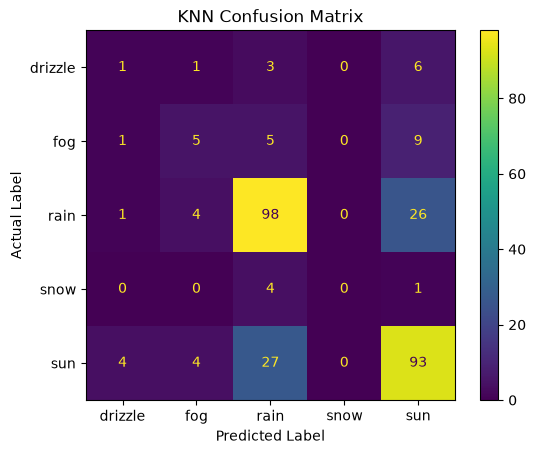

In [14]:
knn_cm = confusion_matrix(y_test, y_pred_knn)

print("Confusion Matrix - KNN")
print(knn_cm)

ConfusionMatrixDisplay(
    confusion_matrix=knn_cm,
    display_labels=knn.classes_
).plot()

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)


In [16]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [17]:
y_pred_rf = rf.predict(X_test)

In [18]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)

print("Accuracy  :", round(rf_accuracy, 4))
print("Precision :", round(rf_precision, 4))
print("Recall    :", round(rf_recall, 4))
print("F1-Score  :", round(rf_f1, 4))



RANDOM FOREST
Accuracy  : 0.8191
Precision : 0.8352
Recall    : 0.8191
F1-Score  : 0.8235


In [19]:
print("\nClassification Report - Random Forest")
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))


Classification Report - Random Forest
              precision    recall  f1-score   support

     drizzle       0.22      0.36      0.28        11
         fog       0.41      0.35      0.38        20
        rain       0.97      0.91      0.94       129
        snow       1.00      0.40      0.57         5
         sun       0.81      0.86      0.84       128

    accuracy                           0.82       293
   macro avg       0.68      0.58      0.60       293
weighted avg       0.84      0.82      0.82       293



Confusion Matrix - Random Forest
[[  4   2   0   0   5]
 [  1   7   0   0  12]
 [  4   0 117   0   8]
 [  0   0   3   2   0]
 [  9   8   1   0 110]]


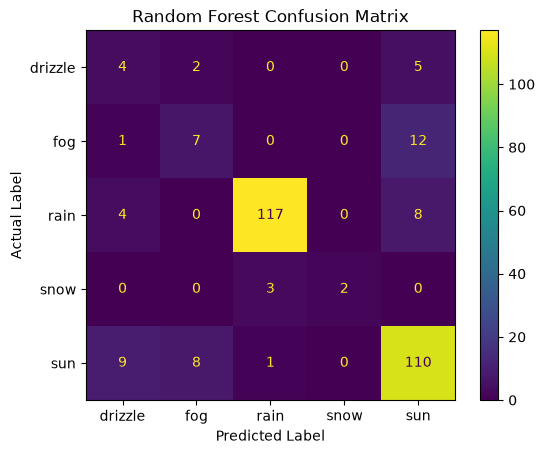

In [20]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix - Random Forest")
print(rf_cm)

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=rf.classes_
).plot()

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


In [21]:
results = pd.DataFrame({
    "Algorithm": [
        "KNN",
        "Random Forest"
    ],

    "Accuracy": [
        knn_accuracy,
        rf_accuracy
    ],

    "Precision": [
        knn_precision,
        rf_precision
    ],

    "Recall": [
        knn_recall,
        rf_recall
    ],

    "F1-Score": [
        knn_f1,
        rf_f1
    ]
})

print("\n" + "=" * 60)
print("ALGORITHM COMPARISON")
print("=" * 60)

print(results.round(4))


ALGORITHM COMPARISON
       Algorithm  Accuracy  Precision  Recall  F1-Score
0            KNN    0.6724     0.6456  0.6724    0.6576
1  Random Forest    0.8191     0.8352  0.8191    0.8235
